In [1]:
import pandas as pd

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

print("\nColumns:\n", train_df.columns)

train_df.head()



Train Shape: (22750, 9)
Test Shape: (12250, 8)

Columns:
 Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available', 'Designation', 'Resource Allocation',
       'Mental Fatigue Score', 'Burn Rate'],
      dtype='object')


,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [2]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [3]:
train_df.isnull().sum()

Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64

In [4]:
test_df.columns


Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available', 'Designation', 'Resource Allocation',
       'Mental Fatigue Score'],
      dtype='object')

In [5]:
test_df.isnull().sum()

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
dtype: int64

In [6]:
train_df = train_df.dropna(subset=["Burn Rate"])
train_df.isnull().sum()

Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1278
Mental Fatigue Score    1945
Burn Rate                  0
dtype: int64

In [7]:
train_df["Mental Fatigue Score"] = train_df["Mental Fatigue Score"].fillna(train_df["Mental Fatigue Score"].median())
train_df.isnull().sum()

Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1278
Mental Fatigue Score       0
Burn Rate                  0
dtype: int64

In [8]:
train_df["Resource Allocation"] = train_df["Resource Allocation"].fillna(train_df["Resource Allocation"].median())
train_df.isnull().sum()

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
Burn Rate               0
dtype: int64

In [9]:
train_df.duplicated().sum()

np.int64(0)

In [10]:
test_df.duplicated().sum()

np.int64(0)

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21626 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           21626 non-null  object 
 1   Date of Joining       21626 non-null  object 
 2   Gender                21626 non-null  object 
 3   Company Type          21626 non-null  object 
 4   WFH Setup Available   21626 non-null  object 
 5   Designation           21626 non-null  float64
 6   Resource Allocation   21626 non-null  float64
 7   Mental Fatigue Score  21626 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [12]:
train_df["Date of Joining"] = pd.to_datetime(train_df["Date of Joining"])

In [13]:
train_df["join_year"] = train_df["Date of Joining"].dt.year

In [14]:
train_df["join_month"] = train_df["Date of Joining"].dt.month

In [15]:
train_df["join_day"] = train_df["Date of Joining"].dt.day

In [16]:
train_df = train_df.drop("Date of Joining",axis=1)

In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21626 entries, 0 to 22749
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           21626 non-null  object 
 1   Gender                21626 non-null  object 
 2   Company Type          21626 non-null  object 
 3   WFH Setup Available   21626 non-null  object 
 4   Designation           21626 non-null  float64
 5   Resource Allocation   21626 non-null  float64
 6   Mental Fatigue Score  21626 non-null  float64
 7   Burn Rate             21626 non-null  float64
 8   join_year             21626 non-null  int32  
 9   join_month            21626 non-null  int32  
 10  join_day              21626 non-null  int32  
dtypes: float64(4), int32(3), object(4)
memory usage: 1.7+ MB


In [18]:
train_df.head()

,Employee ID,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate,join_year,join_month,join_day
0,fffe32003000360033003200,Female,Service,No,2.0,3.0,3.8,0.16,2008,9,30
1,fffe3700360033003500,Male,Service,Yes,1.0,2.0,5.0,0.36,2008,11,30
2,fffe31003300320037003900,Female,Product,Yes,2.0,4.0,5.8,0.49,2008,3,10
3,fffe32003400380032003900,Male,Service,Yes,1.0,1.0,2.6,0.20,2008,11,3
4,fffe31003900340031003600,Female,Service,No,3.0,7.0,6.9,0.52,2008,7,24


In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = ["Gender","Company Type","WFH Setup Available"]
for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])

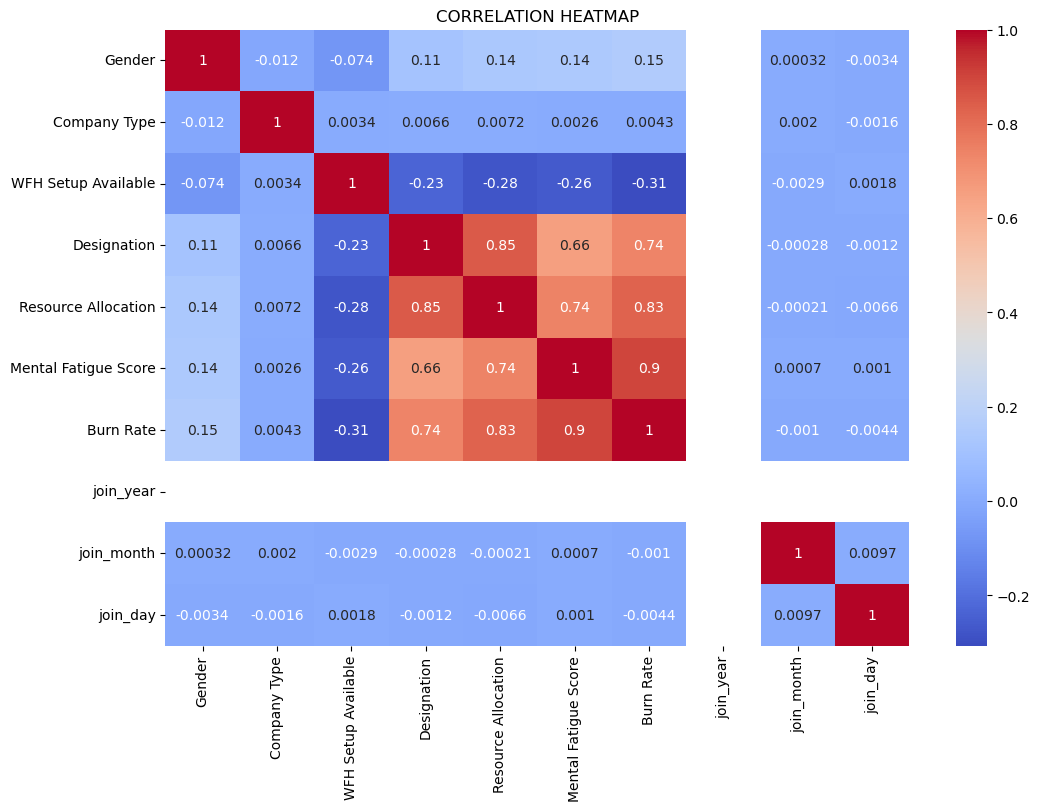

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,8))
numeric_df = train_df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("CORRELATION HEATMAP")
plt.show()

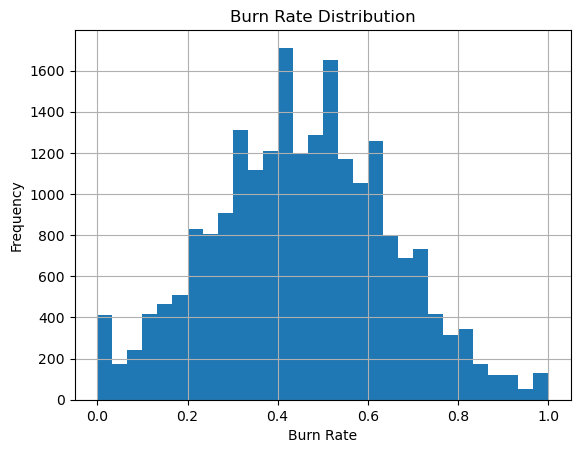

In [21]:

train_df['Burn Rate'].hist(bins=30)

plt.title("Burn Rate Distribution")
plt.xlabel("Burn Rate")
plt.ylabel("Frequency")

plt.show()

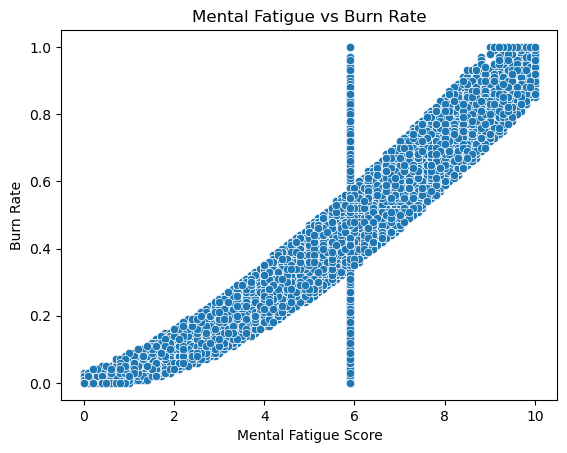

In [22]:
sns.scatterplot(
    x=train_df['Mental Fatigue Score'],
    y=train_df['Burn Rate']
)

plt.title("Mental Fatigue vs Burn Rate")
plt.show()

In [23]:
train_df['Mental Fatigue Score'].value_counts()

Mental Fatigue Score
5.9    2384
6.0     451
5.8     436
6.3     432
5.6     426
       ... 
0.2      22
0.6      22
0.4      16
0.1      15
0.3      11
Name: count, Length: 101, dtype: int64

In [24]:
train_df.corr(numeric_only=True)["Burn Rate"].sort_values(ascending=False)



Burn Rate               1.000000
Mental Fatigue Score    0.898926
Resource Allocation     0.829632
Designation             0.737556
Gender                  0.154895
Company Type            0.004281
join_month             -0.001033
join_day               -0.004395
WFH Setup Available    -0.306266
join_year                    NaN
Name: Burn Rate, dtype: float64

In [25]:
 train_df['join_year'].nunique()

1

In [26]:
train_df = train_df.drop('join_year', axis=1)


In [27]:
train_df.groupby('WFH Setup Available')['Burn Rate'].mean()

WFH Setup Available
0    0.517824
1    0.396010
Name: Burn Rate, dtype: float64

In [28]:
train_df.groupby('Gender')['Burn Rate'].mean()


Gender
0    0.422788
1    0.484271
Name: Burn Rate, dtype: float64

In [29]:
train_df.groupby('Company Type')['Burn Rate'].mean()


Company Type
0    0.450841
1    0.452624
Name: Burn Rate, dtype: float64

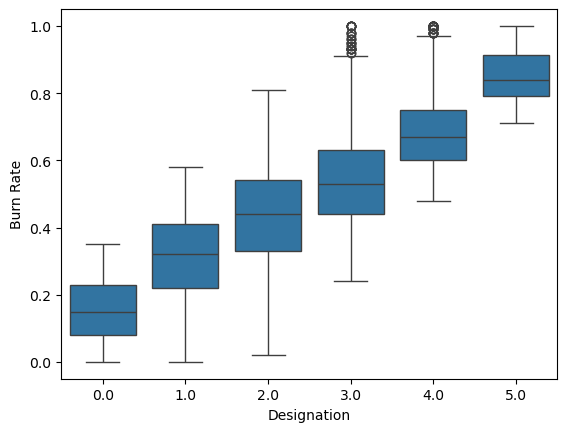

In [30]:
sns.boxplot(
    x='Designation',
    y='Burn Rate',
    data=train_df
)
plt.show()

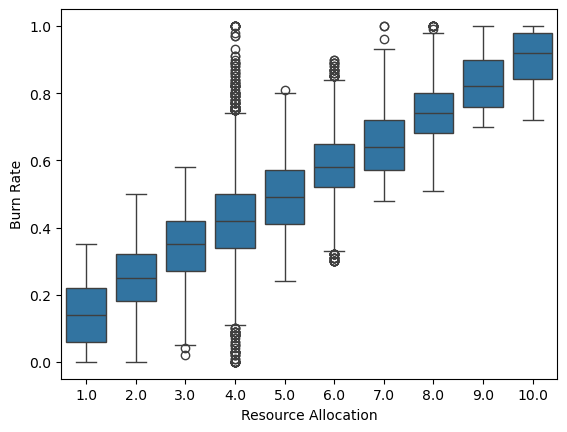

In [31]:
sns.boxplot(
    x='Resource Allocation',
    y='Burn Rate',
    data=train_df
)
plt.show()

In [32]:
x = train_df.drop("Burn Rate", axis =1)
y = train_df["Burn Rate"]

In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42)

In [34]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(17300, 9)
(4326, 9)
(17300,)
(4326,)


In [35]:
x_train = x_train.drop(columns=["Employee ID"])
x_test = x_test.drop(columns=["Employee ID"])

In [36]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
y_pred = lr.predict(x_test)

In [38]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8678929203487885


In [39]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 0.05348535918720067


In [40]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE:", rmse)

RMSE: 0.0709348241381954


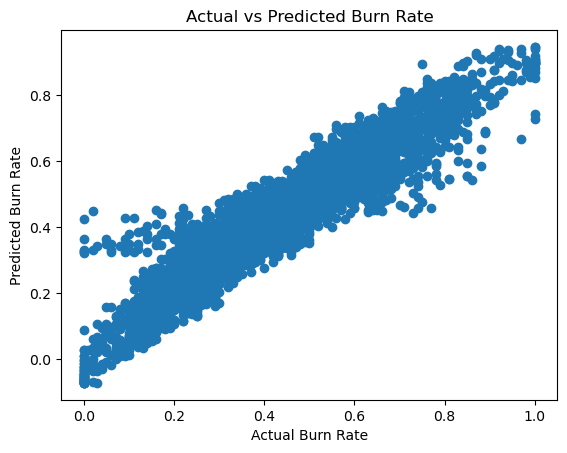

In [41]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Burn Rate")
plt.ylabel("Predicted Burn Rate")
plt.title("Actual vs Predicted Burn Rate")
plt.show()

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf= RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(x_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
rf_pred = rf.predict(x_test)

In [44]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

print("R²:", r2_score(y_test, rf_pred))

print("MAE:", mean_absolute_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

R²: 0.89310528211222
MAE: 0.049321948333810345
RMSE: 0.06380791782599124


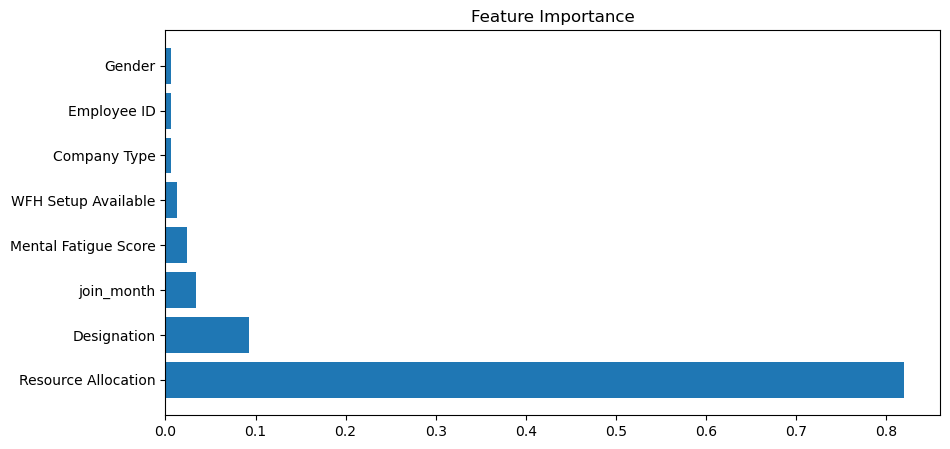

In [45]:
import matplotlib.pyplot as plt

n = min(len(x.columns), len(rf.feature_importances_))

importance = pd.DataFrame({
    'Feature': x.columns[:n],
    'Importance': rf.feature_importances_[:n]
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,5))
plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")
plt.show()

In [46]:
X2 = train_df.drop(
    ['Burn Rate', 'Mental Fatigue Score', "Employee ID"],
    axis=1
)

y = train_df['Burn Rate']


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

rf2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf2.fit(X_train, y_train)

pred2 = rf2.predict(X_test)

print("R²:", r2_score(y_test, pred2))

R²: 0.6530956772333205


In [60]:
print(type(rf))
print(x_test.shape)

<class 'sklearn.ensemble._forest.RandomForestRegressor'>
(4326, 8)


In [61]:
import shap

In [62]:
import shap
print(shap.__version__)

0.52.0


In [63]:
explainer = shap.TreeExplainer(rf)
print("Explainer created")


Explainer created


In [64]:
sample_X = x_test.sample(10, random_state=42)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(sample_X)

print("SHAP calculated")

SHAP calculated


In [65]:
print(rf)

RandomForestRegressor(n_estimators=200, random_state=42)


In [66]:
print(type(shap_values))
print(len(shap_values))

<class 'numpy.ndarray'>
10


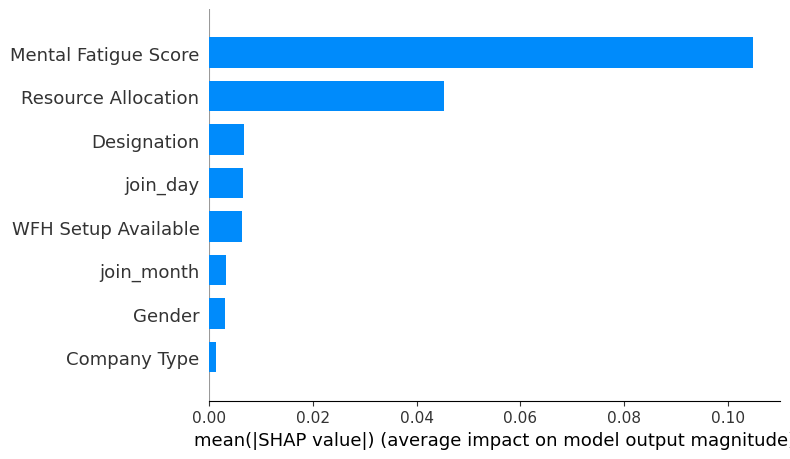

In [67]:
shap.summary_plot(
    shap_values,
    sample_X,
    plot_type="bar"
)

In [68]:
print(x_test.columns)

Index(['Gender', 'Company Type', 'WFH Setup Available', 'Designation',
       'Resource Allocation', 'Mental Fatigue Score', 'join_month',
       'join_day'],
      dtype='object')


In [69]:
def burnout_risk(score):
    if score < 0.33:
        return "Low"
    elif score < 0.66:
        return "Medium"
    else:
        return "High"

train_df['Risk_Level'] = train_df['Burn Rate'].apply(burnout_risk)

In [70]:
import joblib

joblib.dump(rf, "burnout_model.pkl")

['burnout_model.pkl']

In [76]:
joblib.dump(le, "gender_encoder.pkl")
joblib.dump(le,"wfh_encoder.pkl")
joblib.dump(le,"company_encoder.pkl")

['company_encoder.pkl']

In [77]:
import joblib
import pandas as pd

model = joblib.load("burnout_model.pkl")

employee = pd.DataFrame({
    'Gender':[1],
    'Company Type':[0],
    'WFH Setup Available':[1],
    'Designation':[3],
    'Resource Allocation':[8],
    'Mental Fatigue Score':[8.5],
    'join_month':[5],
    'join_day':[15]
})

prediction = model.predict(employee)

print(prediction)

[0.78135]


In [78]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [84]:
import os

print(os.getcwd())

C:\Users\surya


In [85]:
import os

print(os.listdir())

['-1.14-windows.xml', '.anaconda', '.conda', '.crawl4ai', '.git', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.matplotlib', '.streamlit', '.viminfo', '.vscode', '.wdm', 'app.py', 'AppData', 'Application Data', 'battery-report.html', 'cd', 'company_encoder.pkl', 'Cookies', 'Documents', 'Downloads', 'Employee_burnout.ipynb', 'Favorites', 'gender_encoder.pkl', 'global.yml', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'Numpy Practice.ipynb', 'OneDrive', 'PrintHood', 'Project', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'suryansh-varshney-portfolio', 'test.csv', 'tra